<a href="https://colab.research.google.com/github/Sarayu2205/MLOPs/blob/main/data_preprocessing_pipeline_using_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving CSE_Employability_Dataset.xlsx to CSE_Employability_Dataset.xlsx


libraries impoting

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

load dataset

In [ ]:
df = pd.read_excel("CSE_Employability_Dataset.xlsx")

print("First 5 Records")

df.head()

First 5 Records


,StudentID,Age,Gender,CGPA,Programming,DSA,DBMS,OS,CN,Python,...,DevOps,CyberSecurity,Communication,Aptitude,Teamwork,Internship,Certifications,Projects,PlacementTraining,Employability
0,1,20,Male,8.69,7,7,7,6,6,8,...,7,7,6,7,10,Yes,5,5,Yes,High
1,2,23,Male,7.43,5,4,4,6,5,5,...,3,6,3,5,7,No,0,4,Yes,High
2,3,23,Male,7.87,7,7,6,5,4,6,...,5,4,7,6,8,Yes,5,3,Yes,High
3,4,22,Female,6.40,2,3,1,1,1,1,...,2,1,1,1,7,No,2,1,Yes,Medium
4,5,24,Female,6.41,3,3,4,2,3,2,...,3,2,2,4,5,Yes,0,2,Yes,High


check missing values

In [ ]:
print("Missing Values")

print(df.isnull().sum())

Missing Values
StudentID            0
Age                  0
Gender               0
CGPA                 0
Programming          0
DSA                  0
DBMS                 0
OS                   0
CN                   0
Python               0
Java                 0
WebDevelopment       0
AI_ML                0
Cloud                0
DevOps               0
CyberSecurity        0
Communication        0
Aptitude             0
Teamwork             0
Internship           0
Certifications       0
Projects             0
PlacementTraining    0
Employability        0
dtype: int64


handle missing values

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

print("Missing Values After Handling")

print(df.isnull().sum())

Missing Values After Handling
StudentID            0
Age                  0
Gender               0
CGPA                 0
Programming          0
DSA                  0
DBMS                 0
OS                   0
CN                   0
Python               0
Java                 0
WebDevelopment       0
AI_ML                0
Cloud                0
DevOps               0
CyberSecurity        0
Communication        0
Aptitude             0
Teamwork             0
Internship           0
Certifications       0
Projects             0
PlacementTraining    0
Employability        0
dtype: int64


Encode Categorical Variables

In [ ]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df["Internship"] = encoder.fit_transform(df["Internship"])

df["PlacementTraining"] = encoder.fit_transform(df["PlacementTraining"])

df["Employability"] = encoder.fit_transform(df["Employability"])

df.head()

,StudentID,Age,Gender,CGPA,Programming,DSA,DBMS,OS,CN,Python,...,DevOps,CyberSecurity,Communication,Aptitude,Teamwork,Internship,Certifications,Projects,PlacementTraining,Employability
0,1,20,1,8.69,7,7,7,6,6,8,...,7,7,6,7,10,1,5,5,1,0
1,2,23,1,7.43,5,4,4,6,5,5,...,3,6,3,5,7,0,0,4,1,0
2,3,23,1,7.87,7,7,6,5,4,6,...,5,4,7,6,8,1,5,3,1,0
3,4,22,0,6.40,2,3,1,1,1,1,...,2,1,1,1,7,0,2,1,1,2
4,5,24,0,6.41,3,3,4,2,3,2,...,3,2,2,4,5,1,0,2,1,0


Feature Selection

In [ ]:
X = df.drop(["StudentID","Employability"], axis=1)

y = df["Employability"]

print(X.head())

   Age  Gender  CGPA  Programming  DSA  DBMS  OS  CN  Python  Java  ...  \
0   20       1  8.69            7    7     7   6   6       8     7  ...   
1   23       1  7.43            5    4     4   6   5       5     4  ...   
2   23       1  7.87            7    7     6   5   4       6     8  ...   
3   22       0  6.40            2    3     1   1   1       1     2  ...   
4   24       0  6.41            3    3     4   2   3       2     2  ...   

   Cloud  DevOps  CyberSecurity  Communication  Aptitude  Teamwork  \
0      6       7              7              6         7        10   
1      3       3              6              3         5         7   
2      4       5              4              7         6         8   
3      1       2              1              1         1         7   
4      4       3              2              2         4         5   

   Internship  Certifications  Projects  PlacementTraining  
0           1               5         5                  1  
1     

Normalize / Scale Data

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.33948994  1.          0.83299275  0.60613202  0.64203874  0.74058784
   0.38767846  0.44508286  0.92882824  0.53613629  0.32961713  0.4382262
   0.40700319  0.7257659   0.77367273  0.46114788  0.72867568  1.58048587
   0.63910148  1.53997165  1.24272106  0.65465367]
 [ 0.83265591  1.         -0.17971553 -0.11118398 -0.42802583 -0.35929509
   0.38767846  0.08322688 -0.10320314 -0.49489504 -0.39481612  0.06996889
  -0.69300543 -0.66993776  0.40700319 -0.64560703 -0.01109658 -0.14368053
  -1.56469673 -1.45608215  0.54456316  0.65465367]
 [ 0.83265591  1.          0.17392863  0.60613202  0.64203874  0.3739602
   0.03841859 -0.27862911  0.24080732  0.8798134  -0.0325995   0.4382262
  -0.32633589  0.02791407 -0.32633589  0.83006618  0.35878955  0.4310416
   0.63910148  1.53997165 -0.15359474  0.65465367]
 [ 0.10860729 -1.         -1.00756436 -1.18715799 -0.78471401 -1.45917802
  -1.35862091 -1.36419707 -1.47924497 -1.18224926 -0.75703274 -1.03480305
  -1.42634451 -1.01886367 -1.42634451

Split Dataset into Training and Testing

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(

    X_scaled,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Shape :",X_train.shape)

print("Testing Shape :",X_test.shape)

Training Shape : (80, 22)
Testing Shape : (20, 22)


Automate Preprocessing using Pipeline

In [ ]:
pipeline = Pipeline([

    ('scaler',StandardScaler())

])

X_train_pipeline = pipeline.fit_transform(X_train)

X_test_pipeline = pipeline.transform(X_test)

print("Pipeline Completed Successfully")

Pipeline Completed Successfully


Save Processed Dataset

In [ ]:
processed_df = pd.DataFrame(X_scaled,columns=X.columns)

processed_df["Employability"] = y.values

processed_df.to_excel(

    "Processed_CSE_Employability_Dataset.xlsx",

    index=False

)

print("Processed Dataset Saved Successfully")

Processed Dataset Saved Successfully


Compare Before and After Preprocessing

In [ ]:
print("Before Scaling")

print(X.describe())

Before Scaling
              Age      Gender        CGPA  Programming         DSA  \
count  100.000000  100.000000  100.000000   100.000000  100.000000   
mean    21.850000    0.500000    7.653600     5.310000    5.200000   
std      1.388081    0.502519    1.250456     2.802218    2.817693   
min     20.000000    0.000000    5.510000     1.000000    1.000000   
25%     21.000000    0.000000    6.630000     3.000000    2.750000   
50%     22.000000    0.500000    7.710000     5.000000    5.000000   
75%     23.000000    1.000000    8.785000     8.000000    8.000000   
max     24.000000    1.000000    9.720000    10.000000   10.000000   

             DBMS          OS          CN      Python        Java  ...  \
count  100.000000  100.000000  100.000000  100.000000  100.000000  ...   
mean     4.980000    4.890000    4.770000    5.300000    5.440000  ...   
std      2.741304    2.877622    2.777453    2.921533    2.924366  ...   
min      1.000000    1.000000    1.000000    1.000000    1

After Scaling

In [ ]:
scaled_df = pd.DataFrame(

    X_scaled,

    columns=X.columns

)

print("After Scaling")

print(scaled_df.describe())

After Scaling
                Age      Gender          CGPA   Programming           DSA  \
count  1.000000e+02  100.000000  1.000000e+02  1.000000e+02  1.000000e+02   
mean  -9.947598e-16    0.000000  7.771561e-16  1.521006e-16 -8.659740e-17   
std    1.005038e+00    1.005038  1.005038e+00  1.005038e+00  1.005038e+00   
min   -1.339490e+00   -1.000000 -1.722890e+00 -1.545816e+00 -1.498090e+00   
25%   -6.154413e-01   -1.000000 -8.227049e-01 -8.285000e-01 -8.738861e-01   
50%    1.086073e-01    0.000000  4.533075e-02 -1.111840e-01 -7.133764e-02   
75%    8.326559e-01    1.000000  9.093477e-01  9.647900e-01  9.987269e-01   
max    1.556705e+00    1.000000  1.660842e+00  1.682106e+00  1.712103e+00   

               DBMS            OS            CN        Python          Java  \
count  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02   
mean  -1.365574e-16  8.763823e-17  1.321165e-16  3.108624e-17 -1.576517e-16   
std    1.005038e+00  1.005038e+00  1.005038e+00  1.0050

Compare Using Graph

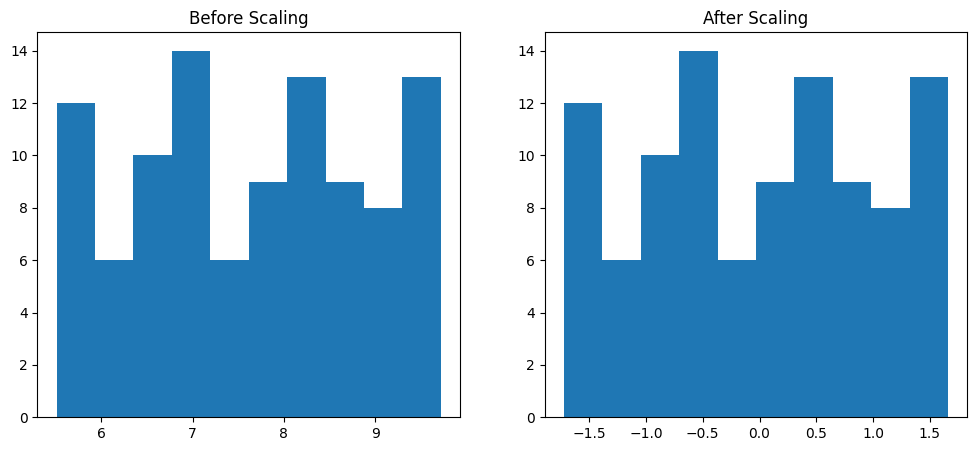

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.hist(X["CGPA"])

plt.title("Before Scaling")

plt.subplot(1,2,2)

plt.hist(scaled_df["CGPA"])

plt.title("After Scaling")

plt.show()